# Gas Turbine CO and NOx Emissions Modeling

This notebook turns an earlier assignment-style analysis into a reproducible machine learning project. The goal is to predict gas turbine emissions from operating and ambient measurements, compare several regression approaches, and document the tradeoffs in a way that would be clear to a portfolio reviewer.

## 1. Introduction

Gas turbines are instrumented systems: temperature, pressure, humidity, and turbine operating variables are all measured continuously. This project uses those measurements to model two emissions outputs:

- `CO`: carbon monoxide concentration
- `NOX`: nitrogen oxides concentration, written as NOx in narrative text

The primary task is supervised regression. A small classification experiment appears near the end, but it is intentionally labeled as exploratory because the threshold used there is data-derived, not a regulatory standard.

## 2. Dataset Source

The data comes from the UCI Machine Learning Repository:

- Dataset: Gas Turbine CO and NOx Emission Data Set
- UCI dataset id: `551`
- DOI: `10.24432/C5WC95`
- Source page: https://archive.ics.uci.edu/dataset/551/gas+turbine+co+and+nox+emission+data+set

The cleaned notebook uses the project loader in `src/emissions_ml/data.py`, which fetches the dataset through `ucimlrepo` and normalizes the returned table into features and targets. If network access is unavailable, place an equivalent raw CSV at `data/raw/gas_turbine_emissions.csv`; raw data files are intentionally ignored by Git.

## 3. Data Loading

The loader returns three tables:

- `features`: predictor columns only
- `targets`: `CO` and `NOX`
- `frame`: the joined modeling table

In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists() and (PROJECT_ROOT.parent / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.base import clone
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.multioutput import MultiOutputRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR

from emissions_ml.data import TARGET_COLUMNS, load_emissions_data

RANDOM_STATE = 42
IMAGE_DIR = PROJECT_ROOT / "images"
IMAGE_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)

In [2]:
LOCAL_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "gas_turbine_emissions.csv"

try:
    emissions = load_emissions_data()
    data_source = "UCI Machine Learning Repository via ucimlrepo"
except Exception as exc:
    if LOCAL_DATA_PATH.exists():
        emissions = load_emissions_data(local_path=LOCAL_DATA_PATH)
        data_source = f"Local fallback file: {LOCAL_DATA_PATH}"
    else:
        raise RuntimeError(
            "Could not fetch UCI dataset id 551 and no local fallback file was found. "
            f"Place an equivalent raw CSV at {LOCAL_DATA_PATH} if running offline."
        ) from exc

frame = emissions.frame.copy()
features = emissions.features.copy()
targets = emissions.targets.copy()

print(data_source)
print(f"Rows: {frame.shape[0]:,}")
print(f"Columns: {frame.shape[1]:,}")
frame.head()

UCI Machine Learning Repository via ucimlrepo
Rows: 36,733
Columns: 12


,year,AT,AP,AH,AFDP,GTEP,TIT,TAT,TEY,CDP,CO,NOX
0,2011,4.5878,1018.7,83.675,3.5758,23.979,1086.2,549.83,134.67,11.898,0.32663,81.952
1,2011,4.2932,1018.3,84.235,3.5709,23.951,1086.1,550.05,134.67,11.892,0.44784,82.377
2,2011,3.9045,1018.4,84.858,3.5828,23.990,1086.5,550.19,135.10,12.042,0.45144,83.776
3,2011,3.7436,1018.3,85.434,3.5808,23.911,1086.5,550.17,135.03,11.990,0.23107,82.505
4,2011,3.7516,1017.8,85.182,3.5781,23.917,1085.9,550.00,134.67,11.910,0.26747,82.028


## 4. Data Quality Checks

Before modeling, check shape, data types, missingness, duplicates, target availability, and the year coverage. The `year` column is useful for validation design, but it is not treated as an operating sensor in the feature matrix.

In [3]:
quality_summary = pd.DataFrame({
    "dtype": frame.dtypes.astype(str),
    "missing_count": frame.isna().sum(),
    "missing_rate": frame.isna().mean(),
    "unique_values": frame.nunique(),
})

print(f"Duplicate rows: {frame.duplicated().sum():,}")
print(f"Target columns: {list(TARGET_COLUMNS)}")
print(f"Year range: {int(frame['year'].min())} to {int(frame['year'].max())}")
quality_summary

Duplicate rows: 7
Target columns: ['CO', 'NOX']
Year range: 2011 to 2015


,dtype,missing_count,missing_rate,unique_values
year,int64,0,0.0,5
AT,float64,0,0.0,22523
AP,float64,0,0.0,791
AH,float64,0,0.0,25708
AFDP,float64,0,0.0,20495
GTEP,float64,0,0.0,12967
TIT,float64,0,0.0,799
TAT,float64,0,0.0,2769
TEY,float64,0,0.0,6236
CDP,float64,0,0.0,4447


In [4]:
frame.describe().T

,count,mean,std,min,25%,50%,75%,max
year,36733.0,2012.985735,1.418965,2011.000000,2012.0000,2013.0000,2014.0000,2015.0000
AT,36733.0,17.712726,7.447451,-6.234800,11.7810,17.8010,23.6650,37.1030
AP,36733.0,1013.070165,6.463346,985.850000,1008.8000,1012.6000,1017.0000,1036.6000
AH,36733.0,77.867015,14.461355,24.085000,68.1880,80.4700,89.3760,100.2000
AFDP,36733.0,3.925518,0.773936,2.087400,3.3556,3.9377,4.3769,7.6106
GTEP,36733.0,25.563801,4.195957,17.698000,23.1290,25.1040,29.0610,40.7160
TIT,36733.0,1081.428084,17.536373,1000.800000,1071.8000,1085.9000,1097.0000,1100.9000
TAT,36733.0,546.158517,6.842360,511.040000,544.7200,549.8800,550.0400,550.6100
TEY,36733.0,133.506404,15.618634,100.020000,124.4500,133.7300,144.0800,179.5000
CDP,36733.0,12.060525,1.088795,9.851800,11.4350,11.9650,12.8550,15.1590


## 5. Exploratory Data Analysis

The exploratory pass focuses on target distributions and correlation structure. These plots are saved to `images/` so the repository can reuse them in the README or project writeup.

Saved /Users/michaelowen/projects/emissions-ml/images/correlation_heatmap.png


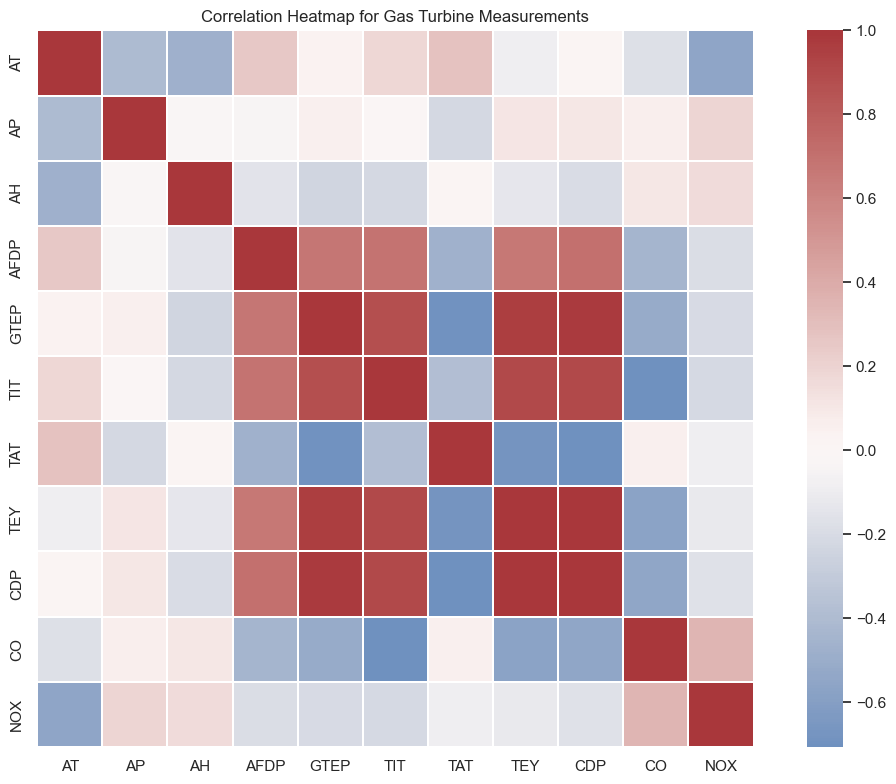

In [5]:
def save_current_figure(filename):
    path = IMAGE_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    print(f"Saved {path}")

plt.figure(figsize=(11, 8))
corr = frame.drop(columns=["year"]).corr(numeric_only=True)
sns.heatmap(corr, cmap="vlag", center=0, square=True, linewidths=0.25)
plt.title("Correlation Heatmap for Gas Turbine Measurements")
save_current_figure("correlation_heatmap.png")
plt.show()

Saved /Users/michaelowen/projects/emissions-ml/images/co_distribution.png

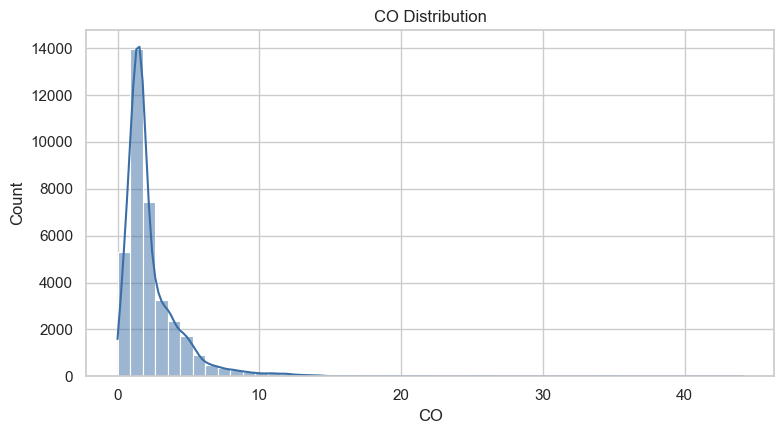

In [6]:
plt.figure(figsize=(8, 4.5))
sns.histplot(frame["CO"], bins=50, kde=True, color="#3a6ea5")
plt.title("CO Distribution")
plt.xlabel("CO")
plt.ylabel("Count")
save_current_figure("co_distribution.png")
plt.show()

Saved /Users/michaelowen/projects/emissions-ml/images/nox_distribution.png


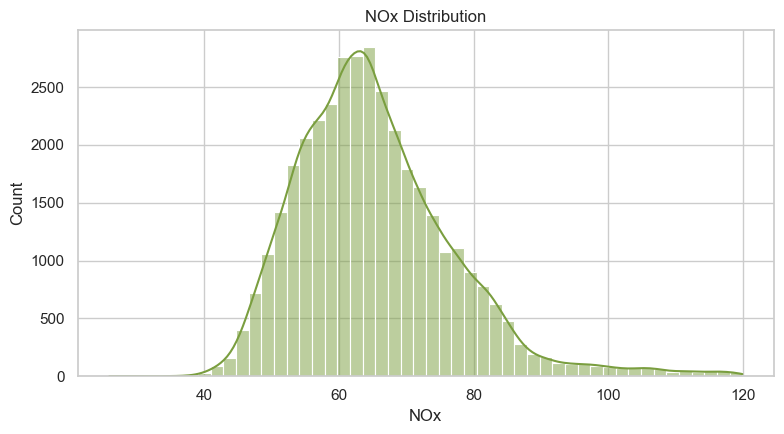

In [7]:
plt.figure(figsize=(8, 4.5))
sns.histplot(frame["NOX"], bins=50, kde=True, color="#7a9e3f")
plt.title("NOx Distribution")
plt.xlabel("NOx")
plt.ylabel("Count")
save_current_figure("nox_distribution.png")
plt.show()

In [8]:
year_target_summary = frame.groupby("year")[list(TARGET_COLUMNS)].agg(["mean", "median", "std", "count"])
year_target_summary.rename(columns={"NOX": "NOx"}, level=0)

CO                                NOx                          
          mean  median       std count       mean   median        std count
year                                                                       
2011  1.572486  1.1557  1.845442  7411  67.575392  65.5420  10.683331  7411
2012  2.361133  1.6363  2.474116  7628  68.788965  67.2465  10.224937  7628
2013  2.723031  1.7827  2.363913  7152  70.007899  68.6510  12.048249  7152
2014  2.081103  1.6553  2.006939  7158  60.066886  59.2785   9.971729  7158
2015  3.129986  2.5334  2.234962  7384  59.890509  56.8385  11.132464  7384

## 6. Feature and Target Definition

The project models `CO` and `NOX` together as a multi-output regression problem. The `year` column is retained for chronological validation design, then removed from the predictors so the models learn from physical and operating measurements rather than collection-year labels.

In [9]:
target_columns = list(TARGET_COLUMNS)
display_target_columns = {"CO": "CO", "NOX": "NOx"}
feature_columns = [column for column in frame.columns if column not in target_columns + ["year"]]

X = frame[feature_columns]
y = frame[target_columns]

year = frame["year"]
train_years = [2011, 2012, 2013]
validation_year = 2014
holdout_year = 2015

train_mask = year.isin(train_years)
validation_mask = year == validation_year
holdout_mask = year == holdout_year

X_train = X.loc[train_mask].copy()
y_train = y.loc[train_mask].copy()
X_validation = X.loc[validation_mask].copy()
y_validation = y.loc[validation_mask].copy()
X_holdout = X.loc[holdout_mask].copy()
y_holdout = y.loc[holdout_mask].copy()

print(f"Feature columns ({len(feature_columns)}): {feature_columns}")
print(f"Training rows: {X_train.shape[0]:,} ({min(train_years)}-{max(train_years)})")
print(f"Validation rows: {X_validation.shape[0]:,} ({validation_year})")
print(f"Final holdout rows: {X_holdout.shape[0]:,} ({holdout_year})")

Feature columns (9): ['AT', 'AP', 'AH', 'AFDP', 'GTEP', 'TIT', 'TAT', 'TEY', 'CDP']
Training rows: 22,191 (2011-2013)
Validation rows: 7,158 (2014)
Final holdout rows: 7,384 (2015)


## 7. Modeling Strategy

Three regression families are compared:

- Ridge regression with `StandardScaler` as a stable linear baseline
- Random forest regression as a tree-based nonlinear model
- Support vector regression with `StandardScaler`, wrapped for multi-output prediction

The split is chronological: train on 2011-2013, compare models on 2014, and reserve 2015 as a final holdout year. This avoids choosing the model directly on the final test period. All preprocessing is inside scikit-learn pipelines, so scalers are fit only on the training data.

In [10]:
def regression_metrics(model_name, y_true, y_pred):
    rows = []
    for target in y_true.columns:
        rmse = mean_squared_error(y_true[target], y_pred[target]) ** 0.5
        rows.append({
            "model": model_name,
            "target": target,
            "r2": r2_score(y_true[target], y_pred[target]),
            "rmse": rmse,
            "mae": mean_absolute_error(y_true[target], y_pred[target]),
        })
    return pd.DataFrame(rows)


def _predict_ridge_pipeline(model, X_values):
    transformed = X_values
    for _, step in model.steps[:-1]:
        transformed = step.transform(transformed)
    ridge = model.named_steps["model"]
    return np.dot(transformed, ridge.coef_.T) + ridge.intercept_


def predict_dataframe(model, X_values, columns):
    if isinstance(model, Pipeline) and isinstance(model.named_steps.get("model"), Ridge):
        predictions = _predict_ridge_pipeline(model, X_values)
    else:
        predictions = model.predict(X_values)
    return pd.DataFrame(predictions, columns=columns, index=X_values.index)


def fit_and_score(name, estimator, X_fit, y_fit, X_eval, y_eval):
    model = clone(estimator)
    model.fit(X_fit, y_fit)
    predictions = predict_dataframe(model, X_eval, y_eval.columns)
    metrics = regression_metrics(name, y_eval, predictions)
    return model, predictions, metrics

## 8. Baseline Regression Model

Ridge regression replaces plain linear regression as the baseline. Gas turbine sensor variables are often correlated, and Ridge regularization gives the linear benchmark more numerical stability while keeping the model simple and interpretable.

In [11]:
ridge_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0, solver="lsqr")),
])

ridge_model, ridge_validation_predictions, ridge_validation_metrics = fit_and_score(
    "Ridge Regression", ridge_pipeline, X_train, y_train, X_validation, y_validation
)
ridge_validation_metrics.assign(target=lambda df: df["target"].replace(display_target_columns))

,model,target,r2,rmse,mae
0,Ridge Regression,CO,0.417772,1.531264,0.908123
1,Ridge Regression,NOx,0.253061,8.617529,6.535341


## 9. Tree-Based Regression Model

The random forest captures nonlinear relationships and feature interactions without scaling. It can also model both targets directly.

In [12]:
forest_model_spec = RandomForestRegressor(
    n_estimators=150,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

forest_model, forest_validation_predictions, forest_validation_metrics = fit_and_score(
    "Random Forest", forest_model_spec, X_train, y_train, X_validation, y_validation
)
forest_validation_metrics.assign(target=lambda df: df["target"].replace(display_target_columns))

,model,target,r2,rmse,mae
0,Random Forest,CO,0.431707,1.512829,0.787543
1,Random Forest,NOx,-0.133829,10.617297,9.153419


## 10. Support Vector Regression Model

Kernel SVR can be effective on nonlinear regression problems, but it scales poorly with row count. To keep this notebook practical and reproducible, the SVR model is trained on a deterministic sample of the training set, then evaluated on the same 2015 holdout set.

In [13]:
svr_train_rows = min(5000, len(X_train))
svr_sample_index = X_train.sample(n=svr_train_rows, random_state=RANDOM_STATE).index

svr_pipeline = MultiOutputRegressor(
    Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1, gamma="scale")),
    ])
)

svr_model, svr_validation_predictions, svr_validation_metrics = fit_and_score(
    "RBF SVR", svr_pipeline,
    X_train.loc[svr_sample_index], y_train.loc[svr_sample_index],
    X_validation, y_validation,
)
svr_validation_metrics.assign(target=lambda df: df["target"].replace(display_target_columns))

,model,target,r2,rmse,mae
0,RBF SVR,CO,0.201453,1.793304,1.244089
1,RBF SVR,NOx,-0.203672,10.939419,9.503164


## 11. Model Comparison

Models are selected on the 2014 validation year. Lower RMSE/MAE is better, while higher R2 is better. The best model is selected by average validation RMSE across `CO` and NOx, then evaluated once on the untouched 2015 final holdout year.

In [14]:
validation_metrics = pd.concat(
    [ridge_validation_metrics, forest_validation_metrics, svr_validation_metrics],
    ignore_index=True,
)
validation_summary = (
    validation_metrics
    .groupby("model", as_index=False)
    .agg(r2=("r2", "mean"), rmse=("rmse", "mean"), mae=("mae", "mean"))
    .sort_values("rmse")
)

validation_summary

,model,r2,rmse,mae
2,Ridge Regression,0.335417,5.074397,3.721732
1,Random Forest,0.148939,6.065063,4.970481
0,RBF SVR,-0.001110,6.366361,5.373627


In [15]:
model_specs = {
    "Ridge Regression": ridge_pipeline,
    "Random Forest": forest_model_spec,
    "RBF SVR": svr_pipeline,
}
validation_predictions_by_model = {
    "Ridge Regression": ridge_validation_predictions,
    "Random Forest": forest_validation_predictions,
    "RBF SVR": svr_validation_predictions,
}

best_model_name = validation_summary.iloc[0]["model"]
best_model = clone(model_specs[best_model_name])

if best_model_name == "RBF SVR":
    best_model.fit(X_train.loc[svr_sample_index], y_train.loc[svr_sample_index])
else:
    best_model.fit(X_train, y_train)

holdout_predictions = predict_dataframe(best_model, X_holdout, y_holdout.columns)
holdout_metrics = regression_metrics(best_model_name, y_holdout, holdout_predictions)

print(f"Best model by 2014 validation average RMSE: {best_model_name}")
holdout_metrics.assign(target=lambda df: df["target"].replace(display_target_columns))

Best model by 2014 validation average RMSE: Ridge Regression


,model,target,r2,rmse,mae
0,Ridge Regression,CO,0.025504,2.206129,1.688867
1,Ridge Regression,NOx,-0.133753,11.852802,10.173504


Saved /Users/michaelowen/projects/emissions-ml/images/model_comparison.png


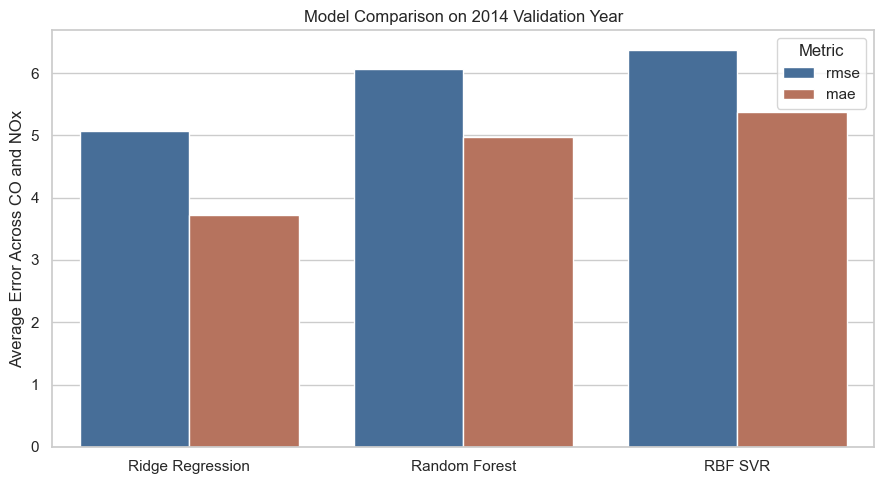

In [16]:
plt.figure(figsize=(9, 5))
summary_long = validation_summary.melt(
    id_vars="model",
    value_vars=["rmse", "mae"],
    var_name="metric",
    value_name="value",
)
sns.barplot(data=summary_long, x="model", y="value", hue="metric", palette=["#3a6ea5", "#c56b4f"])
plt.title("Model Comparison on 2014 Validation Year")
plt.xlabel("")
plt.ylabel("Average Error Across CO and NOx")
plt.legend(title="Metric")
save_current_figure("model_comparison.png")
plt.show()

Saved /Users/michaelowen/projects/emissions-ml/images/actual_vs_predicted_best_model.png


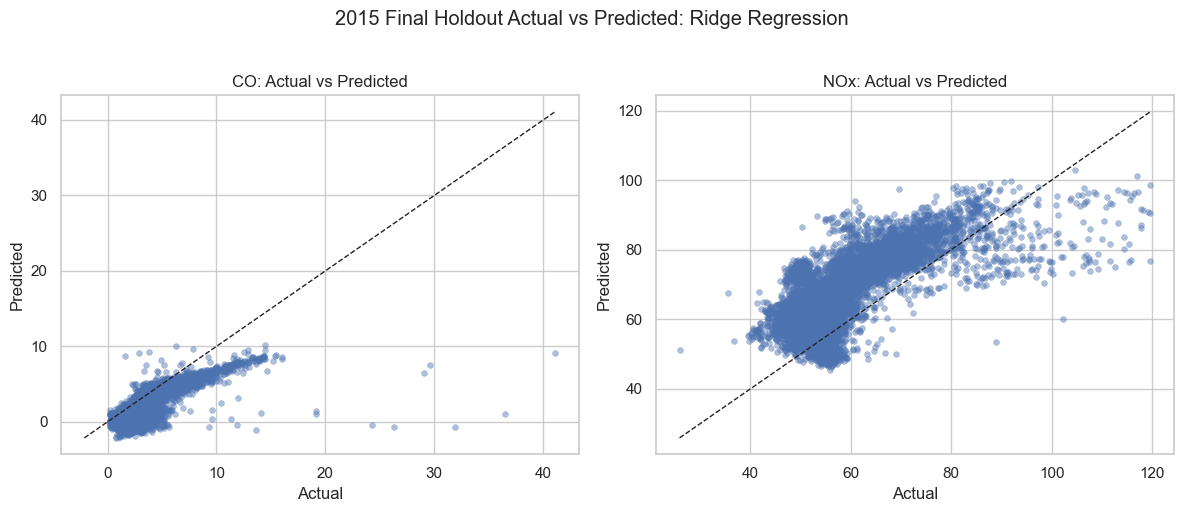

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, target in zip(axes, target_columns):
    label = display_target_columns.get(target, target)
    sns.scatterplot(x=y_holdout[target], y=holdout_predictions[target], s=18, alpha=0.45, ax=ax, edgecolor=None)
    lower = min(y_holdout[target].min(), holdout_predictions[target].min())
    upper = max(y_holdout[target].max(), holdout_predictions[target].max())
    ax.plot([lower, upper], [lower, upper], color="#222222", linestyle="--", linewidth=1)
    ax.set_title(f"{label}: Actual vs Predicted")
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
fig.suptitle(f"2015 Final Holdout Actual vs Predicted: {best_model_name}", y=1.02)
save_current_figure("actual_vs_predicted_best_model.png")
plt.show()

In [18]:
validation_by_target = validation_metrics.pivot(index="target", columns="model", values="rmse")
baseline_name = "Ridge Regression"
best_validation_by_target = validation_by_target.idxmin(axis=1)
co_best = best_validation_by_target.get("CO")
nox_best = best_validation_by_target.get("NOX")
co_holdout_rmse = holdout_metrics.loc[holdout_metrics["target"] == "CO", "rmse"].iloc[0]
nox_holdout_rmse = holdout_metrics.loc[holdout_metrics["target"] == "NOX", "rmse"].iloc[0]
baseline_rmse = validation_summary.loc[validation_summary["model"] == baseline_name, "rmse"].iloc[0]
best_rmse = validation_summary.iloc[0]["rmse"]
relative_improvement = (baseline_rmse - best_rmse) / baseline_rmse

if best_model_name == baseline_name:
    nonlinear_takeaway = (
        "The tree and SVR models were not clearly better on average than the Ridge baseline, "
        "although the target-level validation results show where nonlinear structure may still help."
    )
else:
    nonlinear_takeaway = (
        f"The strongest validation model improved average RMSE by {relative_improvement:.1%} versus "
        "the Ridge baseline, so nonlinear modeling added useful signal beyond the stable linear benchmark."
    )

interpretation = f"""
### Interpretation

The best model on the 2014 validation year was **{best_model_name}**, selected by average RMSE across CO and NOx. On the final 2015 holdout set, its RMSE was **{co_holdout_rmse:.3f}** for CO and **{nox_holdout_rmse:.3f}** for NOx.

Validation performance was target-dependent: CO was best handled by **{co_best}**, while NOx was best handled by **{nox_best}**. {nonlinear_takeaway}

NOx can be harder to predict when its behavior shifts by year or depends on operating regimes that are only partly captured by the available sensor columns. That is one reason the chronological split is useful: it highlights whether a model transfers to later collection periods rather than only fitting a random sample well.
"""
print(interpretation)


### Interpretation

The best model on the 2014 validation year was **Ridge Regression**, selected by average RMSE across CO and NOx. On the final 2015 holdout set, its RMSE was **2.206** for CO and **11.853** for NOx.

Validation performance was target-dependent: CO was best handled by **Random Forest**, while NOx was best handled by **Ridge Regression**. The tree and SVR models were not clearly better on average than the Ridge baseline, although the target-level validation results show where nonlinear structure may still help.

NOx can be harder to predict when its behavior shifts by year or depends on operating regimes that are only partly captured by the available sensor columns. That is one reason the chronological split is useful: it highlights whether a model transfers to later collection periods rather than only fitting a random sample well.



## 12. Optional Classification Experiment

This section is exploratory. It converts `CO` into a binary label using the median `CO` value from the 2011-2013 training period. That threshold is useful for a modeling demonstration, but it is not a compliance threshold and should not be interpreted as a regulatory claim.

A random forest classifier is used here after logistic regression produced numerical warnings in this environment. The classifier avoids scaling and keeps the optional experiment separate from the primary regression workflow.

In [19]:
co_threshold = float(y_train["CO"].median())
y_train_high_co = (y_train["CO"] > co_threshold).astype(int)
y_validation_high_co = (y_validation["CO"] > co_threshold).astype(int)
y_holdout_high_co = (y_holdout["CO"] > co_threshold).astype(int)

classification_model = RandomForestClassifier(
    n_estimators=150,
    min_samples_leaf=2,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
classification_model.fit(X_train, y_train_high_co)
validation_class_predictions = classification_model.predict(X_validation)
holdout_class_predictions = classification_model.predict(X_holdout)

classification_results = pd.DataFrame([
    {
        "evaluation_period": "2014 validation",
        "threshold_basis": "2011-2013 training median CO",
        "threshold_value": co_threshold,
        "accuracy": accuracy_score(y_validation_high_co, validation_class_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_validation_high_co, validation_class_predictions),
    },
    {
        "evaluation_period": "2015 final holdout",
        "threshold_basis": "2011-2013 training median CO",
        "threshold_value": co_threshold,
        "accuracy": accuracy_score(y_holdout_high_co, holdout_class_predictions),
        "balanced_accuracy": balanced_accuracy_score(y_holdout_high_co, holdout_class_predictions),
    },
])
classification_results

,evaluation_period,threshold_basis,threshold_value,accuracy,balanced_accuracy
0,2014 validation,2011-2013 training median CO,1.5242,0.779827,0.784968
1,2015 final holdout,2011-2013 training median CO,1.5242,0.640980,0.761043


## 13. Final Takeaways

This cleaned project turns the original homework notebook into a reproducible regression workflow. A few lessons stand out:

- Regression metrics tell different stories: R2 is useful for explained variance, while RMSE and MAE keep the discussion grounded in prediction error.
- Ridge regression is a sensible linear baseline when sensor variables are correlated, but nonlinear models can capture relationships a linear model misses.
- More flexible models can improve validation performance, but they also raise overfitting and runtime concerns.
- Pipelines make preprocessing safer because scaling is learned only from the training data.
- Chronological validation is important here because the data spans multiple collection years. Selecting on 2014 and evaluating once on 2015 gives a more honest portfolio story than choosing a model directly on the final test year.
- The optional classification framing is useful for experimentation, but any emissions compliance threshold would need to come from a cited regulatory source rather than the dataset itself.